In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os, shutil, sys

DRIVE_CODE_DIR = '/content/drive/MyDrive/CSC415-Project'
DRIVE_LOG_DIR  = '/content/drive/MyDrive/CSC415-Project/logs'
WORK_DIR       = '/content/vcrnd'

os.makedirs(WORK_DIR, exist_ok=True)
os.makedirs(DRIVE_LOG_DIR, exist_ok=True)

for f in ['run_minigrid_vcrnd.py']:
    src = os.path.join(DRIVE_CODE_DIR, f)
    dst = os.path.join(WORK_DIR, f)
    if os.path.exists(src):
        shutil.copy(src, dst)
        print(f'\u2713 {f}')
    else:
        print(f'\u2717 {f} NOT FOUND in {DRIVE_CODE_DIR}')

os.chdir(WORK_DIR)
sys.path.insert(0, WORK_DIR)
print(f'\nWorking dir : {WORK_DIR}')
print(f'Log dir     : {DRIVE_LOG_DIR}')

✓ run_minigrid_vcrnd.py

Working dir : /content/vcrnd
Log dir     : /content/drive/MyDrive/CSC415-Project/logs


In [3]:
# PyTorch is pre-installed on Colab. Install remaining deps.
!pip install gymnasium --quiet
!pip install opencv-python-headless --quiet
!pip install minigrid --quiet
!pip install dm_control --quiet
import torch
!pip install scikit-learn --quiet
print(f'\u2713 All deps installed  |  PyTorch {torch.__version__}  |  CUDA: {torch.cuda.is_available()}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.7/136.7 kB 14.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 MB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 153.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 119.2 MB/s eta 0:00:00
✓ All deps installed  |  PyTorch 2.10.0+cu128  |  CUDA: True


In [ ]:
!python run_minigrid_vcrnd.py \
  --condition all \
  --env MiniGrid-FourRooms-v0 \
  --num_env 4 \
  --nsteps 32 \
  --nepochs 2 \
  --nminibatches 2 \
  --num_timesteps 1024 \
  --max_episode_steps 100 \
  --obs_size 56 \
  --hidden_size 128 \
  --lr 1e-4 \
  --ext_coeff 1.0 \
  --int_coeff 0.05 \
  --log_interval 1 \
  --tag smoke_all


  Condition        : ppo
  Env              : MiniGrid-FourRooms-v0
  intrinsic_type   : none
  use_replay_buffer: False
  use_vc_rnd       : False
  vc_rnd_mode      : n/a
  int_coeff        : 0.0
  device           : cuda
  log_dir          : logs/minigrid_vcrnd/smoke_all_ppo

[ppo] Warming up observation normalisation ...
[ppo] Warm-up complete.
[ppo][       128] ep_rew=0.000  int_final=0.0000  vc_scale=1.000  corr=0.000  ev_ext=-8.587  tps=67
[ppo][       256] ep_rew=0.000  int_final=0.0000  vc_scale=1.000  corr=0.000  ev_ext=-1.335  tps=112
[ppo][       384] ep_rew=0.000  int_final=0.0000  vc_scale=1.000  corr=0.000  ev_ext=0.446  tps=145
[ppo][       512] ep_rew=0.000  int_final=0.0000  vc_scale=1.000  corr=0.000  ev_ext=0.025  tps=170
[ppo][       640] ep_rew=0.000  int_final=0.0000  vc_scale=1.000  corr=0.000  ev_ext=-6.022  tps=189
[ppo][       768] ep_rew=0.000  int_final=0.0000  vc_scale=1.000  corr=0.000  ev_ext=-2.533  tps=205
[ppo][       896] ep_rew=0.000  int_final=0.0

In [ ]:
# SMOKE TEST — FourRooms + MultiRoom @ int_coeff=0.02

import os, sys, shutil, subprocess
from pathlib import Path
import pandas as pd
import numpy as np

SCRIPT = Path("/content/drive/MyDrive/CSC415-Project/run_minigrid_vcrnd.py")
LOGROOT = Path("/content/drive/MyDrive/CSC415-Project/logs")
assert SCRIPT.exists(), f"Could not find {SCRIPT}"

if LOGROOT.exists():
    shutil.rmtree(LOGROOT)
LOGROOT.mkdir(parents=True, exist_ok=True)

ENVS = {
    "fourrooms": ("MiniGrid-FourRooms-v0", "500"),
    "multiroom": ("MiniGrid-MultiRoom-N6-v0", "1000"),
}

CONDITIONS = [
    ("ppo",       ["--condition", "ppo"]),
    ("ppo_rnd",   ["--condition", "ppo_rnd",   "--int_coeff", "0.02"]),
    ("ppo_vcrnd", ["--condition", "ppo_vcrnd", "--int_coeff", "0.02"]),
]

results = []

for env_tag, (env_id, max_steps) in ENVS.items():
    for cond_name, cond_args in CONDITIONS:
        run_name = f"{env_tag}_{cond_name}"
        log_dir = str(LOGROOT / env_tag)
        os.makedirs(log_dir, exist_ok=True)

        cmd = [
            sys.executable, str(SCRIPT),
            "--env", env_id,
            "--num_env", "8",
            "--nsteps", "128",
            "--num_timesteps", "50000",
            "--max_episode_steps", max_steps,
            "--obs_size", "56",
            "--ext_coeff", "1.0",
            "--seed", "0",
            "--log_interval", "5",
            "--log_dir", log_dir,
            "--tag", f"smoke_{cond_name}",
        ] + cond_args

        print(f"\n{'='*70}")
        print(f"  {run_name}  |  {env_id}")
        print(f"{'='*70}")

        proc = subprocess.run(cmd, text=True, capture_output=True)
        print(proc.stdout[-2000:])
        if proc.returncode != 0:
            print("STDERR:", proc.stderr[-2000:])
            results.append({"run": run_name, "status": "CRASHED"})
            continue

        csvs = sorted(Path(log_dir).rglob("progress.csv"), key=lambda p: p.stat().st_mtime)
        if not csvs:
            results.append({"run": run_name, "status": "NO CSV"})
            continue

        df = pd.read_csv(csvs[-1])
        results.append({
            "run": run_name,
            "rows": len(df),
            "best_rew": round(df.mean_ep_rew.max(), 4),
            "final_rew": round(df.mean_ep_rew.iloc[-1], 4),
            "final_len": round(df.mean_ep_len.iloc[-1], 1),
            "vc_scale": round(df.vc_scale_mean.iloc[-1], 3),
            "int_final": round(df.mean_int_rew_final.iloc[-1], 3),
            "first_rew": int(df.first_reward_step.iloc[-1]),
            "status": "OK",
        })

summary = pd.DataFrame(results)
print(f"\n{'='*70}")
print("SMOKE TEST SUMMARY — int_coeff=0.02, ext_coeff=1.0")
print(f"{'='*70}")
display(summary)


  fourrooms_ppo  |  MiniGrid-FourRooms-v0

  Condition        : ppo
  Env              : MiniGrid-FourRooms-v0
  use_rnd          : False
  use_replay_buffer: False
  use_vc_rnd       : False
  vc_rnd_mode      : n/a
  int_coeff        : 0.0
  device           : cuda
  log_dir          : /content/drive/MyDrive/CSC415-Project/logs/fourrooms/smoke_ppo_ppo

[ppo] Warming up observation normalisation ...
[ppo] Warm-up complete.
[ppo][      5120] ep_rew=0.003  int_final=0.0000  vc_scale=1.000  corr=0.000  ev_ext=-0.526  tps=583
[ppo][     10240] ep_rew=0.012  int_final=0.0000  vc_scale=1.000  corr=0.000  ev_ext=-0.890  tps=679
[ppo][     15360] ep_rew=0.028  int_final=0.0000  vc_scale=1.000  corr=0.000  ev_ext=-1.987  tps=717
[ppo][     20480] ep_rew=0.049  int_final=0.0000  vc_scale=1.000  corr=0.000  ev_ext=0.011  tps=739
[ppo][     25600] ep_rew=0.046  int_final=0.0000  vc_scale=1.000  corr=0.000  ev_ext=-0.273  tps=753
[ppo][     30720] ep_rew=0.016  int_final=0.0000  vc_scale=1.000  c

,run,rows,best_rew,final_rew,final_len,vc_scale,int_final,first_rew,status
0,fourrooms_ppo,49,0.0554,0.0405,96.4,1.000,0.000,5120,OK
1,fourrooms_ppo_rnd,49,0.0354,0.0000,100.0,1.000,5.576,5120,OK
2,fourrooms_ppo_vcrnd,49,0.0263,0.0091,99.1,0.816,4.308,5120,OK
3,multiroom_ppo,49,0.0000,0.0000,120.0,1.000,0.000,-1,OK
4,multiroom_ppo_rnd,49,0.0000,0.0000,120.0,1.000,7.320,-1,OK
5,multiroom_ppo_vcrnd,49,0.0000,0.0000,120.0,0.841,5.389,-1,OK


In [ ]:
!python run_minigrid_vcrnd.py \
  --condition all \
  --env MiniGrid-FourRooms-v0 \
  --num_env 8 \
  --nsteps 128 \
  --nepochs 4 \
  --nminibatches 4 \
  --num_timesteps 1000000 \
  --max_episode_steps 100 \
  --obs_size 56 \
  --hidden_size 256 \
  --lr 1e-4 \
  --gamma 0.99 \
  --gamma_ext 0.99 \
  --lam 0.95 \
  --cliprange 0.1 \
  --ent_coef 0.001 \
  --max_grad_norm 0.5 \
  --ext_coeff 1.0 \
  --int_coeff 0.02 \
  --rnd_out_dim 512 \
  --vc_rnd_lambda 1.0 \
  --vc_rnd_beta 0.01 \
  --vc_rnd_min_scale 0.0 \
  --replay_buffer_capacity 100 \
  --replay_buffer_replay_ratio 4 \
  --vcse_k 10 \
  --vcse_buffer_capacity 50000 \
  --vcse_value_scale 0.1 \
  --vcse_eps 1e-6 \
  --log_interval 10 \
  --tag fourrooms_all


  Condition        : ppo
  Env              : MiniGrid-FourRooms-v0
  intrinsic_type   : none
  use_replay_buffer: False
  use_vc_rnd       : False
  vc_rnd_mode      : n/a
  int_coeff        : 0.0
  device           : cuda
  log_dir          : logs/minigrid_vcrnd/fourrooms_all_ppo

[ppo] Warming up observation normalisation ...
[ppo] Warm-up complete.
[ppo][     10240] ep_rew=0.019  int_final=0.0000  vc_scale=1.000  corr=0.000  ev_ext=-1.941  tps=282
[ppo][     20480] ep_rew=0.018  int_final=0.0000  vc_scale=1.000  corr=0.000  ev_ext=-0.032  tps=288
[ppo][     30720] ep_rew=0.022  int_final=0.0000  vc_scale=1.000  corr=0.000  ev_ext=-2.880  tps=289
[ppo][     40960] ep_rew=0.026  int_final=0.0000  vc_scale=1.000  corr=0.000  ev_ext=-6.010  tps=290
[ppo][     51200] ep_rew=0.043  int_final=0.0000  vc_scale=1.000  corr=0.000  ev_ext=-3.728  tps=291
[ppo][     61440] ep_rew=0.023  int_final=0.0000  vc_scale=1.000  corr=0.000  ev_ext=-3.231  tps=291
[ppo][     71680] ep_rew=0.014  int_fi

In [ ]:
!python run_minigrid_vcrnd.py \
  --condition ppo \
  --env MiniGrid-FourRooms-v0 \
  --num_env 64 \
  --nsteps 128 \
  --nepochs 4 \
  --nminibatches 4 \
  --num_timesteps 1000000 \
  --max_episode_steps 100 \
  --obs_size 56 \
  --hidden_size 256 \
  --lr 1e-4 \
  --gamma 0.99 \
  --gamma_ext 0.99 \
  --lam 0.95 \
  --cliprange 0.1 \
  --ent_coef 0.001 \
  --max_grad_norm 0.5 \
  --ext_coeff 1.0 \
  --int_coeff 0.02 \
  --rnd_out_dim 512 \
  --vc_rnd_lambda 1.0 \
  --vc_rnd_beta 0.01 \
  --vc_rnd_min_scale 0.0 \
  --replay_buffer_capacity 100 \
  --replay_buffer_replay_ratio 4 \
  --vcse_k 10 \
  --vcse_buffer_capacity 50000 \
  --vcse_value_scale 0.1 \
  --vcse_eps 1e-6 \
  --log_interval 10 \
  --tag fourrooms_ppo


  Condition        : ppo
  Env              : MiniGrid-FourRooms-v0
  intrinsic_type   : none
  use_replay_buffer: False
  use_vc_rnd       : False
  vc_rnd_mode      : n/a
  int_coeff        : 0.0
  device           : cuda
  log_dir          : logs/minigrid_vcrnd/fourrooms_ppo_ppo

[ppo] Warming up observation normalisation ...
[ppo] Warm-up complete.
[ppo][     81920] ep_rew=0.027  int_final=0.0000  vc_scale=1.000  corr=0.000  ev_ext=0.032  tps=748
[ppo][    163840] ep_rew=0.051  int_final=0.0000  vc_scale=1.000  corr=0.000  ev_ext=-0.021  tps=760
[ppo][    245760] ep_rew=0.046  int_final=0.0000  vc_scale=1.000  corr=0.000  ev_ext=-0.041  tps=765
[ppo][    327680] ep_rew=0.087  int_final=0.0000  vc_scale=1.000  corr=0.000  ev_ext=0.075  tps=769
[ppo][    409600] ep_rew=0.104  int_final=0.0000  vc_scale=1.000  corr=0.000  ev_ext=0.298  tps=770
[ppo][    491520] ep_rew=0.202  int_final=0.0000  vc_scale=1.000  corr=0.000  ev_ext=0.545  tps=770
[ppo][    573440] ep_rew=0.206  int_final=

In [ ]:
!python run_minigrid_vcrnd.py \
  --condition ppo_rnd \
  --env MiniGrid-FourRooms-v0 \
  --num_env 64 \
  --nsteps 128 \
  --nepochs 4 \
  --nminibatches 4 \
  --num_timesteps 1000000 \
  --max_episode_steps 100 \
  --obs_size 56 \
  --hidden_size 256 \
  --lr 1e-4 \
  --gamma 0.99 \
  --gamma_ext 0.99 \
  --lam 0.95 \
  --cliprange 0.1 \
  --ent_coef 0.001 \
  --max_grad_norm 0.5 \
  --ext_coeff 1.0 \
  --int_coeff 0.02 \
  --rnd_out_dim 512 \
  --vc_rnd_lambda 1.0 \
  --vc_rnd_beta 0.01 \
  --vc_rnd_min_scale 0.0 \
  --replay_buffer_capacity 100 \
  --replay_buffer_replay_ratio 4 \
  --vcse_k 10 \
  --vcse_buffer_capacity 50000 \
  --vcse_value_scale 0.1 \
  --vcse_eps 1e-6 \
  --log_interval 10 \
  --tag fourrooms_ppo_rnd


  Condition        : ppo_rnd
  Env              : MiniGrid-FourRooms-v0
  intrinsic_type   : rnd
  use_replay_buffer: False
  use_vc_rnd       : False
  vc_rnd_mode      : n/a
  int_coeff        : 0.02
  device           : cuda
  log_dir          : logs/minigrid_vcrnd/fourrooms_ppo_rnd_ppo_rnd

[ppo_rnd] Warming up observation normalisation ...
[ppo_rnd] Warm-up complete.
[ppo_rnd][     81920] ep_rew=0.013  int_final=3.9642  vc_scale=1.000  corr=-0.016  ev_ext=-0.003  tps=597
[ppo_rnd][    163840] ep_rew=0.027  int_final=3.9479  vc_scale=1.000  corr=-0.004  ev_ext=-0.139  tps=603
[ppo_rnd][    245760] ep_rew=0.031  int_final=4.0285  vc_scale=1.000  corr=-0.023  ev_ext=-0.102  tps=607
[ppo_rnd][    327680] ep_rew=0.034  int_final=4.1278  vc_scale=1.000  corr=-0.056  ev_ext=-0.090  tps=609
[ppo_rnd][    409600] ep_rew=0.029  int_final=4.1699  vc_scale=1.000  corr=-0.001  ev_ext=-0.030  tps=611
[ppo_rnd][    491520] ep_rew=0.013  int_final=4.2163  vc_scale=1.000  corr=-0.003  ev_ext=-0.0

In [6]:
import re

SCRIPT = '/content/vcrnd/run_minigrid_vcrnd.py'

with open(SCRIPT, 'r') as f:
    code = f.read()

# 1. Fix sample() — avoid flattening the entire buffer
code = code.replace(
    """    def sample(self, n):
        flat = self._buf[:self.n_segments].reshape(self.n_transitions, *self.obs_shape)
        idxs = np.random.randint(0, self.n_transitions, size=n)
        return flat[idxs]""",
    """    def sample(self, n):
        seg_idxs = np.random.randint(0, self.n_segments, size=n)
        off_idxs = np.random.randint(0, self.seg_size, size=n)
        return self._buf[seg_idxs, off_idxs]"""
)

# 2. Mini-batch the replay predictor update
old_replay = '''        # ── Replay buffer predictor update ───────────────
        replay_rnd_loss = 0.0
        if replay_buf is not None and rnd is not None and replay_buf.n_transitions > 0:
            n_replay = args.replay_buffer_replay_ratio * nenvs * nsteps
            replay_obs_np = replay_buf.sample(n_replay)
            replay_obs_f = replay_obs_np.astype(np.float64)
            replay_obs_norm = (
                (replay_obs_f - obs_rms.mean) / (np.sqrt(obs_rms.var) + eps)
            ).astype(np.float32)
            replay_obs_t = torch.as_tensor(replay_obs_norm, device=device)
            replay_loss = rnd.predictor_loss(replay_obs_t)
            pred_optimizer.zero_grad()
            replay_loss.backward()
            nn.utils.clip_grad_norm_(list(rnd.predictor.parameters()), args.max_grad_norm)
            pred_optimizer.step()
            replay_rnd_loss = replay_loss.item()'''

new_replay = '''        # ── Replay buffer predictor update (mini-batched) ──
        replay_rnd_loss = 0.0
        if replay_buf is not None and rnd is not None and replay_buf.n_transitions > 0:
            n_replay = args.replay_buffer_replay_ratio * nenvs * nsteps
            replay_obs_np = replay_buf.sample(n_replay)
            replay_obs_norm = (
                (replay_obs_np.astype(np.float32) - obs_rms.mean.astype(np.float32))
                / (np.sqrt(obs_rms.var).astype(np.float32) + eps)
            )
            replay_mb_size = max(256, nenvs * nsteps // args.nminibatches)
            replay_loss_sum, replay_n_mbs = 0.0, 0
            for rb_start in range(0, n_replay, replay_mb_size):
                rb_end = min(rb_start + replay_mb_size, n_replay)
                rb_obs_t = torch.as_tensor(replay_obs_norm[rb_start:rb_end], device=device)
                rb_loss = rnd.predictor_loss(rb_obs_t)
                pred_optimizer.zero_grad()
                rb_loss.backward()
                nn.utils.clip_grad_norm_(list(rnd.predictor.parameters()), args.max_grad_norm)
                pred_optimizer.step()
                replay_loss_sum += rb_loss.item()
                replay_n_mbs += 1
            replay_rnd_loss = replay_loss_sum / max(replay_n_mbs, 1)
            del replay_obs_np, replay_obs_norm'''

code = code.replace(old_replay, new_replay)

with open(SCRIPT, 'w') as f:
    f.write(code)

print('✓ Patched replay buffer sampling + mini-batched predictor update')

✓ Patched replay buffer sampling + mini-batched predictor update


In [7]:
!python run_minigrid_vcrnd.py \
  --condition ppo_rnd_replay \
  --env MiniGrid-FourRooms-v0 \
  --num_env 64 \
  --nsteps 128 \
  --nepochs 4 \
  --nminibatches 4 \
  --num_timesteps 1000000 \
  --max_episode_steps 100 \
  --obs_size 56 \
  --hidden_size 256 \
  --lr 1e-4 \
  --gamma 0.99 \
  --gamma_ext 0.99 \
  --lam 0.95 \
  --cliprange 0.1 \
  --ent_coef 0.001 \
  --max_grad_norm 0.5 \
  --ext_coeff 1.0 \
  --int_coeff 0.02 \
  --rnd_out_dim 512 \
  --vc_rnd_lambda 1.0 \
  --vc_rnd_beta 0.01 \
  --vc_rnd_min_scale 0.0 \
  --replay_buffer_capacity 100 \
  --replay_buffer_replay_ratio 4 \
  --vcse_k 10 \
  --vcse_buffer_capacity 50000 \
  --vcse_value_scale 0.1 \
  --vcse_eps 1e-6 \
  --log_interval 10 \
  --tag fourrooms_ppo_rnd_replay


  Condition        : ppo_rnd_replay
  Env              : MiniGrid-FourRooms-v0
  intrinsic_type   : rnd
  use_replay_buffer: True
  use_vc_rnd       : False
  vc_rnd_mode      : n/a
  int_coeff        : 0.02
  device           : cuda
  log_dir          : logs/minigrid_vcrnd/fourrooms_ppo_rnd_replay_ppo_rnd_replay

[ppo_rnd_replay] Warming up observation normalisation ...
[ppo_rnd_replay] Warm-up complete.
[ppo_rnd_replay][     81920] ep_rew=0.016  int_final=0.6042  vc_scale=1.000  corr=0.000  ev_ext=-0.123  tps=458
[ppo_rnd_replay][    163840] ep_rew=0.031  int_final=0.5052  vc_scale=1.000  corr=0.017  ev_ext=-0.064  tps=461
[ppo_rnd_replay][    245760] ep_rew=0.015  int_final=0.3930  vc_scale=1.000  corr=0.170  ev_ext=-0.372  tps=461
[ppo_rnd_replay][    327680] ep_rew=0.010  int_final=0.3266  vc_scale=1.000  corr=-0.152  ev_ext=-0.132  tps=462
[ppo_rnd_replay][    409600] ep_rew=0.019  int_final=0.3189  vc_scale=1.000  corr=-0.114  ev_ext=-0.879  tps=462
[ppo_rnd_replay][    491520]

In [ ]:
!python run_minigrid_vcrnd.py \
  --condition ppo_vcrnd \
  --env MiniGrid-FourRooms-v0 \
  --num_env 64 \
  --nsteps 128 \
  --nepochs 4 \
  --nminibatches 4 \
  --num_timesteps 1000000 \
  --max_episode_steps 100 \
  --obs_size 56 \
  --hidden_size 256 \
  --lr 1e-4 \
  --gamma 0.99 \
  --gamma_ext 0.99 \
  --lam 0.95 \
  --cliprange 0.1 \
  --ent_coef 0.001 \
  --max_grad_norm 0.5 \
  --ext_coeff 1.0 \
  --int_coeff 0.02 \
  --rnd_out_dim 512 \
  --vc_rnd_lambda 1.0 \
  --vc_rnd_beta 0.01 \
  --vc_rnd_min_scale 0.0 \
  --replay_buffer_capacity 100 \
  --replay_buffer_replay_ratio 4 \
  --vcse_k 10 \
  --vcse_buffer_capacity 50000 \
  --vcse_value_scale 0.1 \
  --vcse_eps 1e-6 \
  --log_interval 10 \
  --tag fourrooms_ppo_vcrnd


  Condition        : ppo_vcrnd
  Env              : MiniGrid-FourRooms-v0
  intrinsic_type   : rnd
  use_replay_buffer: False
  use_vc_rnd       : True
  vc_rnd_mode      : inverse
  int_coeff        : 0.02
  device           : cuda
  log_dir          : logs/minigrid_vcrnd/fourrooms_ppo_vcrnd_ppo_vcrnd

[ppo_vcrnd] Warming up observation normalisation ...
[ppo_vcrnd] Warm-up complete.
[ppo_vcrnd][     81920] ep_rew=0.022  int_final=3.6292  vc_scale=0.915  corr=-0.097  ev_ext=-0.111  tps=595
[ppo_vcrnd][    163840] ep_rew=0.034  int_final=3.9797  vc_scale=0.995  corr=-0.020  ev_ext=-0.113  tps=601
[ppo_vcrnd][    245760] ep_rew=0.019  int_final=4.0454  vc_scale=0.997  corr=-0.035  ev_ext=-0.072  tps=604
[ppo_vcrnd][    327680] ep_rew=0.049  int_final=4.0744  vc_scale=0.996  corr=-0.038  ev_ext=-0.025  tps=606
[ppo_vcrnd][    409600] ep_rew=0.054  int_final=4.1789  vc_scale=0.998  corr=0.011  ev_ext=-0.026  tps=607
[ppo_vcrnd][    491520] ep_rew=0.030  int_final=4.1821  vc_scale=0.998  

In [4]:
!python run_minigrid_vcrnd.py \
  --condition ppo_vcrnd_sigmoid \
  --env MiniGrid-FourRooms-v0 \
  --num_env 64 \
  --nsteps 128 \
  --nepochs 4 \
  --nminibatches 4 \
  --num_timesteps 1000000 \
  --max_episode_steps 100 \
  --obs_size 56 \
  --hidden_size 256 \
  --lr 1e-4 \
  --gamma 0.99 \
  --gamma_ext 0.99 \
  --lam 0.95 \
  --cliprange 0.1 \
  --ent_coef 0.001 \
  --max_grad_norm 0.5 \
  --ext_coeff 1.0 \
  --int_coeff 0.02 \
  --rnd_out_dim 512 \
  --vc_rnd_lambda 1.0 \
  --vc_rnd_beta 0.01 \
  --vc_rnd_min_scale 0.0 \
  --replay_buffer_capacity 100 \
  --replay_buffer_replay_ratio 4 \
  --vcse_k 10 \
  --vcse_buffer_capacity 50000 \
  --vcse_value_scale 0.1 \
  --vcse_eps 1e-6 \
  --log_interval 10 \
  --tag fourrooms_ppo_vcrnd_sigmoid


  Condition        : ppo_vcrnd_sigmoid
  Env              : MiniGrid-FourRooms-v0
  intrinsic_type   : rnd
  use_replay_buffer: False
  use_vc_rnd       : True
  vc_rnd_mode      : sigmoid
  int_coeff        : 0.02
  device           : cuda
  log_dir          : logs/minigrid_vcrnd/fourrooms_ppo_vcrnd_sigmoid_ppo_vcrnd_sigmoid

[ppo_vcrnd_sigmoid] Warming up observation normalisation ...
[ppo_vcrnd_sigmoid] Warm-up complete.
[ppo_vcrnd_sigmoid][     81920] ep_rew=0.023  int_final=3.8004  vc_scale=0.964  corr=0.061  ev_ext=-0.009  tps=592
[ppo_vcrnd_sigmoid][    163840] ep_rew=0.035  int_final=3.9753  vc_scale=0.997  corr=0.046  ev_ext=-0.110  tps=601
[ppo_vcrnd_sigmoid][    245760] ep_rew=0.015  int_final=3.9964  vc_scale=0.998  corr=-0.035  ev_ext=-0.091  tps=604
[ppo_vcrnd_sigmoid][    327680] ep_rew=0.025  int_final=4.1533  vc_scale=0.999  corr=-0.042  ev_ext=-0.101  tps=606
[ppo_vcrnd_sigmoid][    409600] ep_rew=0.018  int_final=4.1421  vc_scale=0.998  corr=-0.013  ev_ext=-0.075  t

In [5]:
!python run_minigrid_vcrnd.py \
  --condition ppo_vcse \
  --env MiniGrid-FourRooms-v0 \
  --num_env 64 \
  --nsteps 128 \
  --nepochs 4 \
  --nminibatches 4 \
  --num_timesteps 1000000 \
  --max_episode_steps 100 \
  --obs_size 56 \
  --hidden_size 256 \
  --lr 1e-4 \
  --gamma 0.99 \
  --gamma_ext 0.99 \
  --lam 0.95 \
  --cliprange 0.1 \
  --ent_coef 0.001 \
  --max_grad_norm 0.5 \
  --ext_coeff 1.0 \
  --int_coeff 0.02 \
  --rnd_out_dim 512 \
  --vc_rnd_lambda 1.0 \
  --vc_rnd_beta 0.01 \
  --vc_rnd_min_scale 0.0 \
  --replay_buffer_capacity 100 \
  --replay_buffer_replay_ratio 4 \
  --vcse_k 10 \
  --vcse_buffer_capacity 50000 \
  --vcse_value_scale 0.1 \
  --vcse_eps 1e-6 \
  --log_interval 10 \
  --tag fourrooms_ppo_vcse


  Condition        : ppo_vcse
  Env              : MiniGrid-FourRooms-v0
  intrinsic_type   : vcse
  use_replay_buffer: False
  use_vc_rnd       : False
  vc_rnd_mode      : n/a
  int_coeff        : 0.02
  device           : cuda
  log_dir          : logs/minigrid_vcrnd/fourrooms_ppo_vcse_ppo_vcse

[ppo_vcse] Warming up observation normalisation ...
[ppo_vcse] Warm-up complete.
[ppo_vcse][     81920] ep_rew=0.015  int_final=0.0115  vc_scale=1.000  corr=-0.016  ev_ext=-1.079  tps=633
[ppo_vcse][    163840] ep_rew=0.016  int_final=0.0398  vc_scale=1.000  corr=0.009  ev_ext=0.328  tps=619
[ppo_vcse][    245760] ep_rew=0.028  int_final=0.0135  vc_scale=1.000  corr=0.027  ev_ext=0.032  tps=615
[ppo_vcse][    327680] ep_rew=0.029  int_final=0.0129  vc_scale=1.000  corr=0.092  ev_ext=0.028  tps=615
[ppo_vcse][    409600] ep_rew=0.048  int_final=0.0423  vc_scale=1.000  corr=-0.028  ev_ext=0.316  tps=614
[ppo_vcse][    491520] ep_rew=0.052  int_final=0.0187  vc_scale=1.000  corr=0.073  ev_ext=

✓ PPO                        123 rows
✓ PPO + RND                  123 rows
✓ rnd_replay                 123 rows
✓ VC-RND inverse             123 rows
✓ VC-RND sigmoid             123 rows
✓ VCSE                       123 rows

Generating figures...


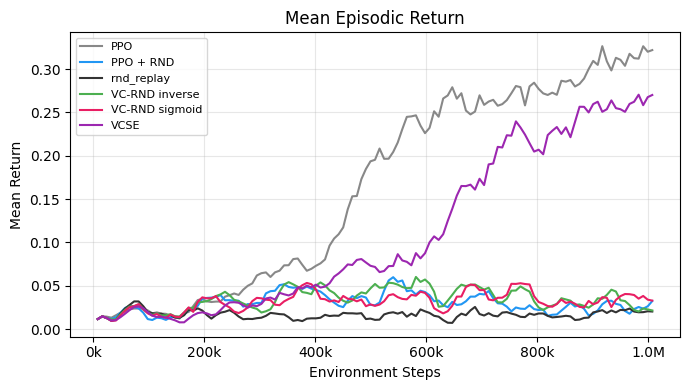

  → fig1_mean_return


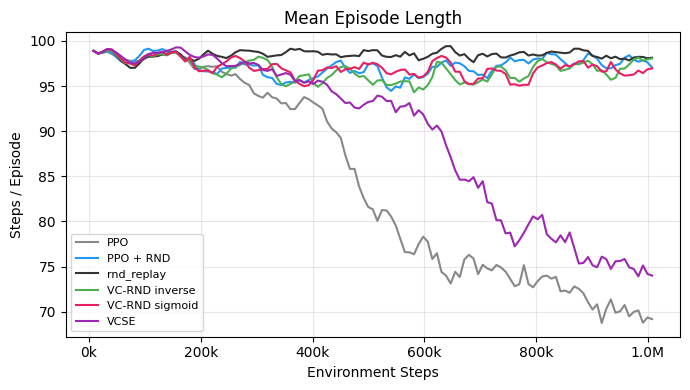

  → fig2_ep_len


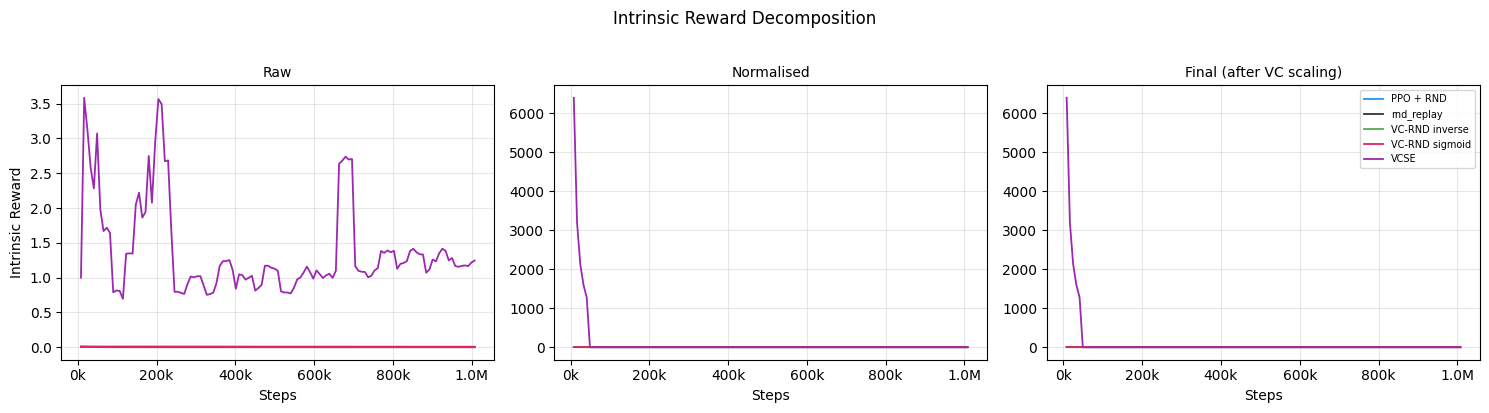

  → fig3_intrinsic_reward


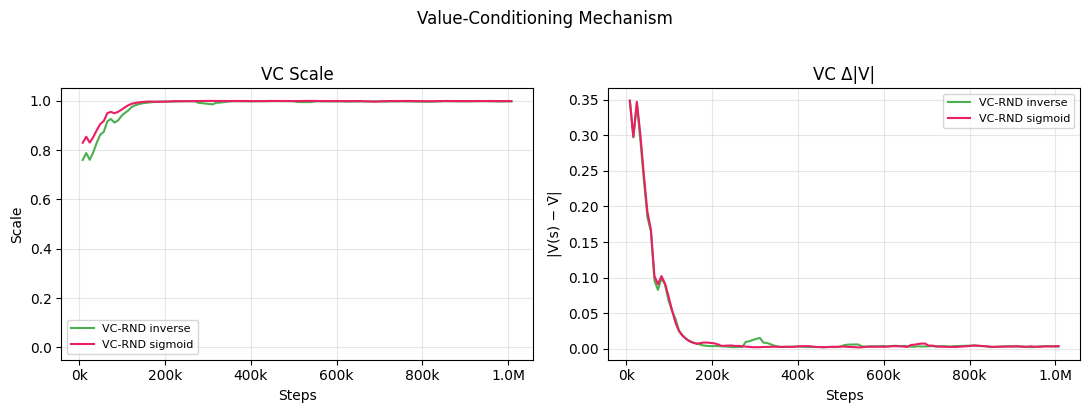

  → fig4_vc_mechanism


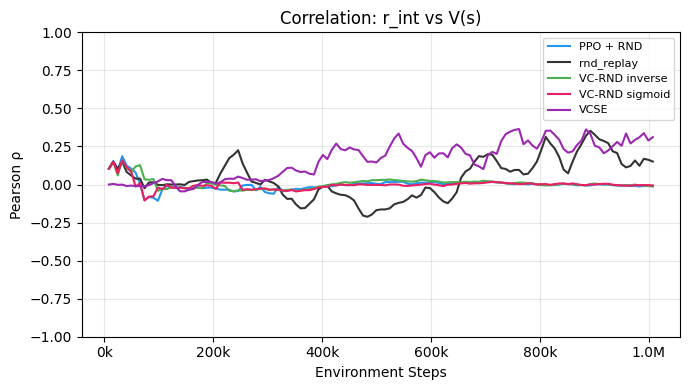

  → fig5_corr_int_v


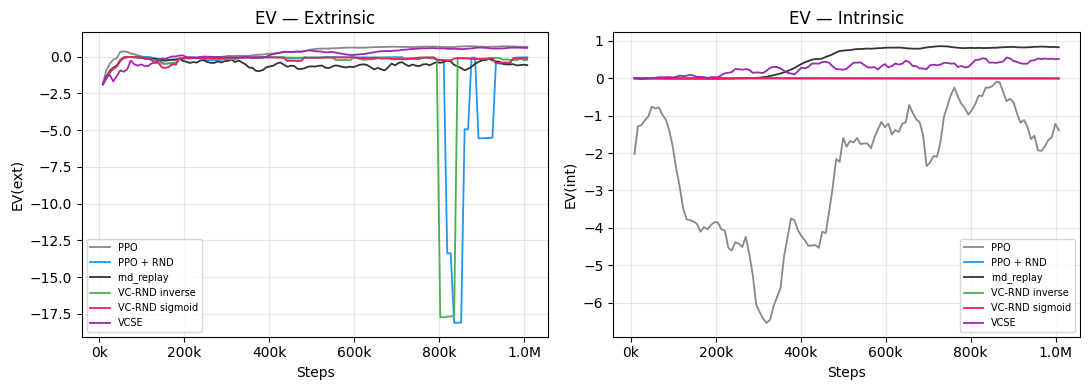

  → fig6_explained_variance


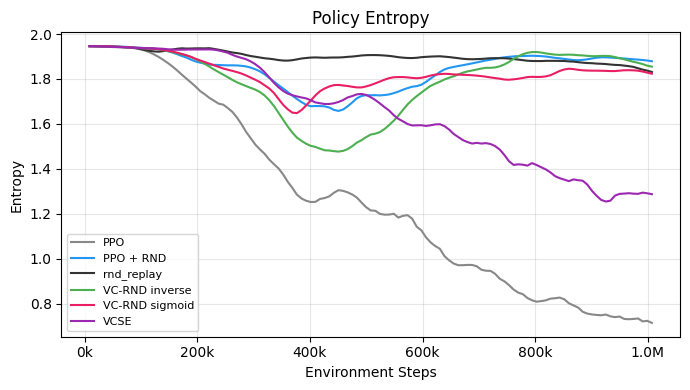

  → fig7_entropy


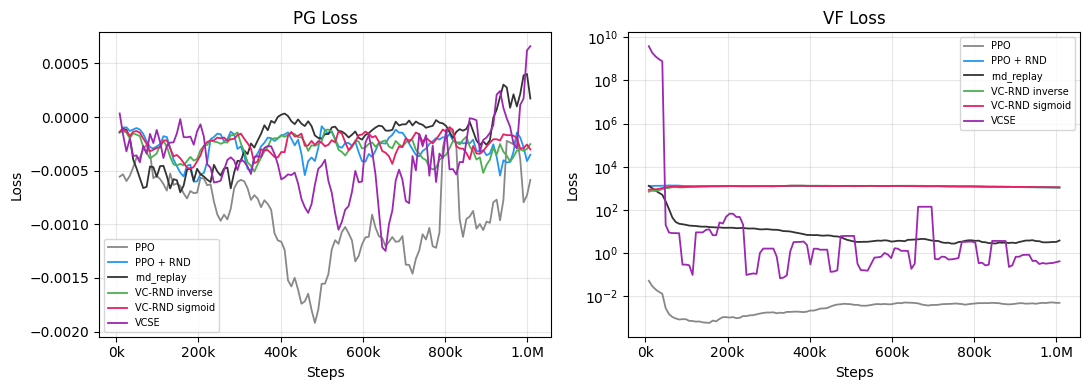

  → fig8_pg_vf_loss


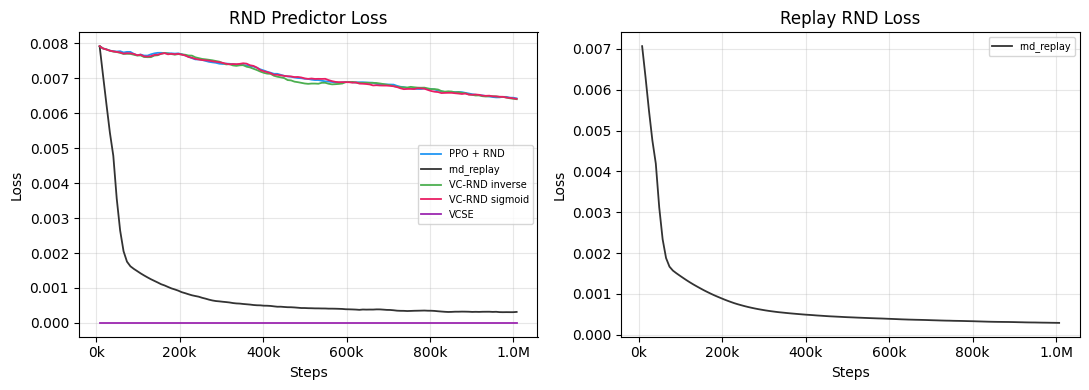

  → fig9_rnd_losses


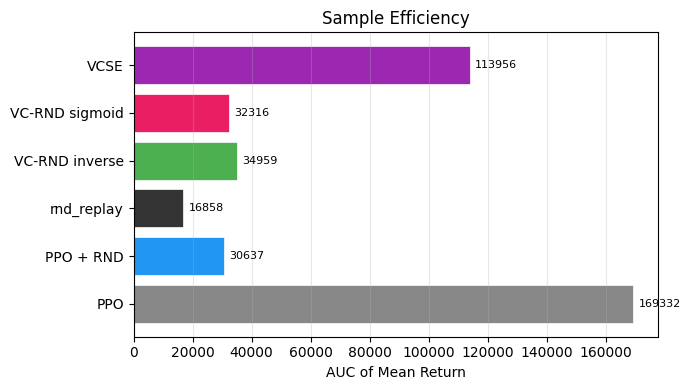

  → fig10_sample_efficiency


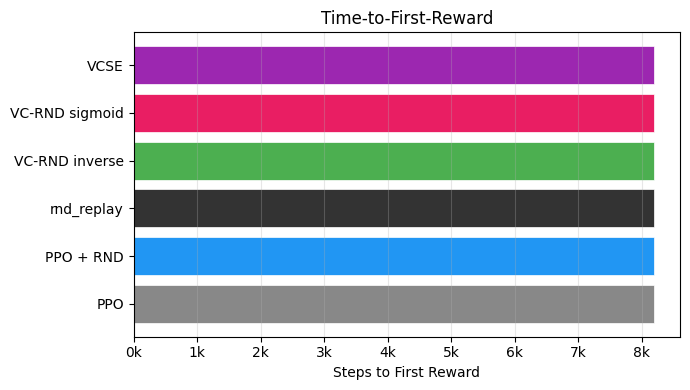

  → fig11_ttfr


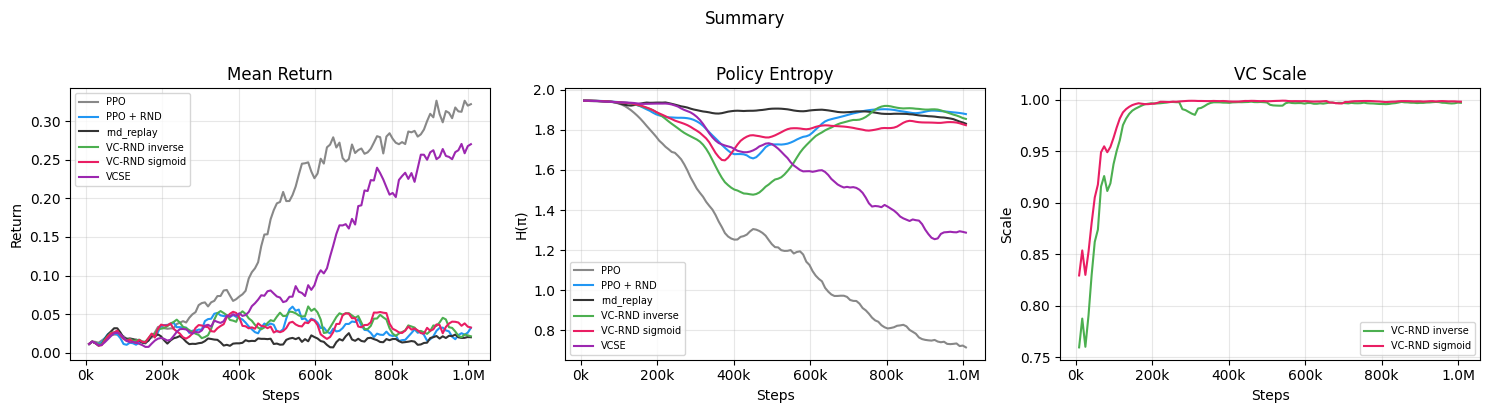

  → fig12_hero_summary

✓ 12 figures saved to /content/drive/MyDrive/CSC415-Project/logs/plots


In [11]:

#
#  Works with two CSV layouts:
#    A) Flat files:   logs/progress_ppo.csv, logs/progress_rnd.csv, ...
#    B) Subfolders:   logs/ppo/progress.csv, logs/fourrooms_ppo/progress.csv, ...
#
#  Saves PDF + PNG to PLOT_DIR (on Drive so they persist).
#  Figures: return, ep_len, intrinsic reward decomposition, VC mechanism,
#           correlation, explained variance, entropy, PG/VF loss,
#           RND losses, sample efficiency (AUC), time-to-first-reward,
#           3-panel hero summary.

import os, glob
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# ── WHERE ARE THE CSVS? ──────────────────────────────────────────
# Option 1: point at a folder with progress_*.csv files
# Option 2: point at a folder with condition subfolders
# The cell tries both automatically.

DRIVE_LOG_DIR = '/content/drive/MyDrive/CSC415-Project/logs'
LOG_DIR = '/content/drive/MyDrive/CSC415-Project/logs'   # <── adjust per env
PLOT_DIR      = os.path.join(DRIVE_LOG_DIR, 'plots')
os.makedirs(PLOT_DIR, exist_ok=True)

# ── CONDITION MAP ─────────────────────────────────────────────────
COND_META = {
    'ppo':              ('PPO',                '#888888'),
    'rnd':              ('PPO + RND',          '#2196F3'),
    'ppo_rnd':          ('PPO + RND',          '#2196F3'),
    'ppo_rnd_replay':   ('PPO + RND + Replay', '#FF9800'),
    'vcrnd_inverse':    ('VC-RND inverse',     '#4CAF50'),
    'ppo_vcrnd':        ('VC-RND inverse',     '#4CAF50'),
    'vcrnd_sigmoid':    ('VC-RND sigmoid',     '#E91E63'),
    'ppo_vcrnd_sigmoid':('VC-RND sigmoid',     '#E91E63'),
    'vcse':             ('VCSE',               '#9C27B0'),
    'ppo_vcse':         ('VCSE',               '#9C27B0'),
}

# ── AUTO-DISCOVER CSVS ───────────────────────────────────────────
data = {}

# Try flat files first: progress_ppo.csv, progress_rnd.csv, ...
for f in sorted(glob.glob(os.path.join(LOG_DIR, 'progress_*.csv'))):
    key = os.path.basename(f).replace('progress_', '').replace('.csv', '')
    label, color = COND_META.get(key, (key, '#333333'))
    if label not in data:
        data[label] = (pd.read_csv(f), color)

# Then try subfolders: ppo/progress.csv, fourrooms_ppo/progress.csv, ...
if not data:
    for d in sorted(os.listdir(LOG_DIR)):
        p = os.path.join(LOG_DIR, d, 'progress.csv')
        if not os.path.isfile(p):
            continue
        # extract condition from folder name (strip any env prefix)
        cond = d.split('_', 1)[-1] if '_' in d else d
        label, color = COND_META.get(cond, COND_META.get(d, (d, '#333333')))
        if label not in data:
            data[label] = (pd.read_csv(p), color)

assert data, f"No CSVs found in {LOG_DIR}  — check the path"
for label, (df, _) in data.items():
    print(f"✓ {label:25s}  {len(df)} rows")

# ── HELPERS ───────────────────────────────────────────────────────
SMOOTH = 5

def sm(y):
    return pd.Series(y).rolling(SMOOTH, min_periods=1).mean().values

def mfmt(x, _):
    return f"{x/1e6:.1f}M" if x >= 1e6 else f"{x/1e3:.0f}k"

def save(fig, name):
    for ext in ['pdf', 'png']:
        fig.savefig(os.path.join(PLOT_DIR, f'{name}.{ext}'),
                    dpi=300, bbox_inches='tight')
    plt.show()
    print(f"  → {name}")

def line(col, title, ylabel, fname, conds=None, yscale='linear', ylim=None):
    fig, ax = plt.subplots(figsize=(7, 4))
    for label, (df, color) in data.items():
        if conds and label not in conds:
            continue
        if col not in df.columns:
            continue
        ax.plot(df['timestep'], sm(df[col]), label=label, color=color, lw=1.5)
    ax.set_xlabel('Environment Steps'); ax.set_ylabel(ylabel)
    ax.set_title(title); ax.set_yscale(yscale)
    if ylim: ax.set_ylim(ylim)
    ax.xaxis.set_major_formatter(FuncFormatter(mfmt))
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    fig.tight_layout(); save(fig, fname)

# conditions that have intrinsic reward
INT_CONDS = [l for l, (df, _) in data.items() if l != 'PPO']
VC_CONDS  = [l for l in data if 'VC-RND' in l]

# ── FIGURES ───────────────────────────────────────────────────────
print("\nGenerating figures...")

# 1  Mean return
line('mean_ep_rew', 'Mean Episodic Return', 'Mean Return', 'fig1_mean_return')

# 2  Episode length
line('mean_ep_len', 'Mean Episode Length', 'Steps / Episode', 'fig2_ep_len')

# 3  Intrinsic reward: raw / norm / final
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, sub in zip(axes,
        ['mean_int_rew_raw', 'mean_int_rew_norm', 'mean_int_rew_final'],
        ['Raw', 'Normalised', 'Final (after VC scaling)']):
    for label, (df, color) in data.items():
        if label == 'PPO' or col not in df.columns: continue
        ax.plot(df['timestep'], sm(df[col]), label=label, color=color, lw=1.3)
    ax.set_title(sub, fontsize=10); ax.set_xlabel('Steps')
    ax.xaxis.set_major_formatter(FuncFormatter(mfmt)); ax.grid(True, alpha=0.3)
axes[0].set_ylabel('Intrinsic Reward')
axes[2].legend(fontsize=7)
fig.suptitle('Intrinsic Reward Decomposition', fontsize=12, y=1.02)
fig.tight_layout(); save(fig, 'fig3_intrinsic_reward')

# 4  VC scale + delta-v
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
for label in VC_CONDS:
    df, color = data[label]
    a1.plot(df['timestep'], sm(df['vc_scale_mean']),   label=label, color=color, lw=1.5)
    a2.plot(df['timestep'], sm(df['vc_delta_v_mean']), label=label, color=color, lw=1.5)
a1.set_title('VC Scale'); a1.set_ylabel('Scale'); a1.set_ylim(-0.05, 1.05)
a2.set_title('VC Δ|V|');  a2.set_ylabel('|V(s) − V̄|')
for a in (a1, a2):
    a.set_xlabel('Steps'); a.xaxis.set_major_formatter(FuncFormatter(mfmt))
    a.legend(fontsize=8); a.grid(True, alpha=0.3)
fig.suptitle('Value-Conditioning Mechanism', fontsize=12, y=1.02)
fig.tight_layout(); save(fig, 'fig4_vc_mechanism')

# 5  Correlation r_int vs V(s)
line('corr_int_v', 'Correlation: r_int vs V(s)', 'Pearson ρ',
     'fig5_corr_int_v', conds=INT_CONDS, ylim=(-1, 1))

# 6  Explained variance
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
for label, (df, color) in data.items():
    a1.plot(df['timestep'], sm(df['ev_ext']), label=label, color=color, lw=1.3)
    a2.plot(df['timestep'], sm(df['ev_int']), label=label, color=color, lw=1.3)
a1.set_title('EV — Extrinsic'); a1.set_ylabel('EV(ext)')
a2.set_title('EV — Intrinsic'); a2.set_ylabel('EV(int)')
for a in (a1, a2):
    a.set_xlabel('Steps'); a.xaxis.set_major_formatter(FuncFormatter(mfmt))
    a.legend(fontsize=7); a.grid(True, alpha=0.3)
fig.tight_layout(); save(fig, 'fig6_explained_variance')

# 7  Entropy
line('entropy', 'Policy Entropy', 'Entropy', 'fig7_entropy')

# 8  PG + VF loss
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
for label, (df, color) in data.items():
    a1.plot(df['timestep'], sm(df['pg_loss']), label=label, color=color, lw=1.3)
    a2.plot(df['timestep'], sm(df['vf_loss']), label=label, color=color, lw=1.3)
a1.set_title('PG Loss');  a1.set_ylabel('Loss')
a2.set_title('VF Loss');  a2.set_ylabel('Loss'); a2.set_yscale('log')
for a in (a1, a2):
    a.set_xlabel('Steps'); a.xaxis.set_major_formatter(FuncFormatter(mfmt))
    a.legend(fontsize=7); a.grid(True, alpha=0.3)
fig.tight_layout(); save(fig, 'fig8_pg_vf_loss')

# 9  RND + replay loss
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
for label in INT_CONDS:
    df, color = data[label]
    a1.plot(df['timestep'], sm(df['rnd_loss']), label=label, color=color, lw=1.3)
    if df['replay_rnd_loss'].sum() > 0:
        a2.plot(df['timestep'], sm(df['replay_rnd_loss']), label=label, color=color, lw=1.3)
a1.set_title('RND Predictor Loss'); a1.set_ylabel('Loss')
a2.set_title('Replay RND Loss');    a2.set_ylabel('Loss')
for a in (a1, a2):
    a.set_xlabel('Steps'); a.xaxis.set_major_formatter(FuncFormatter(mfmt))
    a.legend(fontsize=7); a.grid(True, alpha=0.3)
fig.tight_layout(); save(fig, 'fig9_rnd_losses')

# 10  Sample efficiency (AUC bar chart)
_trapz = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz
fig, ax = plt.subplots(figsize=(7, 4))
aucs = {l: _trapz(df['mean_ep_rew'], df['timestep']) for l, (df, _) in data.items()}
labels = list(aucs.keys()); vals = [aucs[l] for l in labels]
colors = [data[l][1] for l in labels]
bars = ax.barh(labels, vals, color=colors, edgecolor='white', lw=0.5)
ax.set_xlabel('AUC of Mean Return'); ax.set_title('Sample Efficiency')
ax.grid(True, axis='x', alpha=0.3)
for b, v in zip(bars, vals):
    ax.text(v + max(vals)*0.01, b.get_y() + b.get_height()/2, f'{v:.0f}', va='center', fontsize=8)
fig.tight_layout(); save(fig, 'fig10_sample_efficiency')

# 11  Time-to-first-reward
fig, ax = plt.subplots(figsize=(7, 4))
ttfr = {}
for l, (df, _) in data.items():
    frs = df['first_reward_step'].iloc[-1]
    ttfr[l] = frs if frs > 0 else df['timestep'].max()
labels = list(ttfr.keys()); vals = [ttfr[l] for l in labels]
colors = [data[l][1] for l in labels]
ax.barh(labels, vals, color=colors, edgecolor='white', lw=0.5)
ax.set_xlabel('Steps to First Reward'); ax.set_title('Time-to-First-Reward')
ax.xaxis.set_major_formatter(FuncFormatter(mfmt)); ax.grid(True, axis='x', alpha=0.3)
fig.tight_layout(); save(fig, 'fig11_ttfr')

# 12  Hero summary (return + entropy + VC scale)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for label, (df, color) in data.items():
    axes[0].plot(df['timestep'], sm(df['mean_ep_rew']), label=label, color=color, lw=1.5)
    axes[1].plot(df['timestep'], sm(df['entropy']),     label=label, color=color, lw=1.5)
axes[0].set_title('Mean Return');   axes[0].set_ylabel('Return')
axes[1].set_title('Policy Entropy'); axes[1].set_ylabel('H(π)')
for label in VC_CONDS:
    df, color = data[label]
    axes[2].plot(df['timestep'], sm(df['vc_scale_mean']), label=label, color=color, lw=1.5)
axes[2].set_title('VC Scale'); axes[2].set_ylabel('Scale')
for a in axes:
    a.set_xlabel('Steps'); a.xaxis.set_major_formatter(FuncFormatter(mfmt))
    a.legend(fontsize=7); a.grid(True, alpha=0.3)
fig.suptitle('Summary', fontsize=12, y=1.02)
fig.tight_layout(); save(fig, 'fig12_hero_summary')

print(f"\n✓ 12 figures saved to {PLOT_DIR}")


In [12]:

import os, glob
import pandas as pd
import numpy as np

# ── PATHS (same as plot cell) ─────────────────────────────────────
DRIVE_LOG_DIR = '/content/drive/MyDrive/CSC415-Project/logs'
LOG_DIR       = '/content/drive/MyDrive/CSC415-Project/logs'

PLOT_DIR      = os.path.join(DRIVE_LOG_DIR, 'plots')
os.makedirs(PLOT_DIR, exist_ok=True)

# ── CONDITION MAP ─────────────────────────────────────────────────
COND_META = {
    'ppo':              'PPO',
    'rnd':              'PPO + RND',
    'ppo_rnd':          'PPO + RND',
    'rnd_replay':       'PPO + RND + Replay',
    'ppo_rnd_replay':   'PPO + RND + Replay',
    'vcrnd_inverse':    'VC-RND (inverse)',
    'ppo_vcrnd':        'VC-RND (inverse)',
    'vcrnd_sigmoid':    'VC-RND (sigmoid)',
    'ppo_vcrnd_sigmoid':'VC-RND (sigmoid)',
    'vcse':             'VCSE',
    'ppo_vcse':         'VCSE',
}

# ── LOAD DATA ─────────────────────────────────────────────────────
frames = {}

for f in sorted(glob.glob(os.path.join(LOG_DIR, 'progress_*.csv'))):
    key = os.path.basename(f).replace('progress_', '').replace('.csv', '')
    label = COND_META.get(key, key)
    if label not in frames:
        frames[label] = pd.read_csv(f)

if not frames:
    for d in sorted(os.listdir(LOG_DIR)):
        p = os.path.join(LOG_DIR, d, 'progress.csv')
        if not os.path.isfile(p):
            continue
        cond = d.split('_', 1)[-1] if '_' in d else d
        label = COND_META.get(cond, COND_META.get(d, d))
        if label not in frames:
            frames[label] = pd.read_csv(p)

assert frames, f"No CSVs found in {LOG_DIR}"

SMOOTH = 5
_trapz = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz

# ── HELPERS ───────────────────────────────────────────────────────
def sm(s):
    return s.rolling(SMOOTH, min_periods=1).mean()

def save_table(df_table, name, caption, label_tag):
    """Save as .csv and .tex, print to notebook."""
    csv_path = os.path.join(PLOT_DIR, f'{name}.csv')
    tex_path = os.path.join(PLOT_DIR, f'{name}.tex')
    df_table.to_csv(csv_path)

    # LaTeX with booktabs
    latex = df_table.to_latex(
        escape=False,
        column_format='l' + 'r' * len(df_table.columns),
    )
    # wrap in table environment
    full_tex = (
        "\\begin{table}[ht]\n"
        "\\centering\n"
        f"\\caption{{{caption}}}\n"
        f"\\label{{tab:{label_tag}}}\n"
        f"{latex}"
        "\\end{table}\n"
    )
    with open(tex_path, 'w') as f:
        f.write(full_tex)

    print(f"\n{'='*70}")
    print(f"  {caption}")
    print(f"{'='*70}")
    print(df_table.to_string())
    print(f"  → saved {name}.csv + {name}.tex")


# ══════════════════════════════════════════════════════════════════
#  TABLE 1 — Main Results
# ══════════════════════════════════════════════════════════════════

rows = []
for label, df in frames.items():
    n = len(df)
    last_k = max(1, n // 10)  # last 10% of training
    tail = df.iloc[-last_k:]

    mean_ret    = tail['mean_ep_rew'].mean()
    std_ret     = tail['mean_ep_rew'].std()
    final_ret   = df['mean_ep_rew'].iloc[-1]
    mean_len    = tail['mean_ep_len'].mean()

    # peak smoothed return
    smoothed    = sm(df['mean_ep_rew'])
    peak_ret    = smoothed.max()
    peak_step   = df['timestep'].iloc[smoothed.idxmax()]

    # AUC
    auc         = _trapz(df['mean_ep_rew'], df['timestep'])

    # time-to-first-reward
    frs = df['first_reward_step'].iloc[-1]
    ttfr = int(frs) if frs > 0 else None

    # throughput
    mean_tps = df['tps'].mean()

    rows.append({
        'Method':               label,
        'Mean Return (last 10%)': f'{mean_ret:.3f} ± {std_ret:.3f}',
        'Peak Return':          f'{peak_ret:.3f}',
        'Mean Ep. Length':      f'{mean_len:.1f}',
        'AUC':                  f'{auc:.0f}',
        'TTFR (steps)':         f'{ttfr:,}' if ttfr else '—',
        'TPS':                  f'{mean_tps:.0f}',
    })

t1 = pd.DataFrame(rows).set_index('Method')
save_table(t1, 'table1_main_results',
           'Main Results — MiniGrid FourRooms (1M steps)',
           'main_results')


# ══════════════════════════════════════════════════════════════════
#  TABLE 2 — Intrinsic Reward Analysis
# ══════════════════════════════════════════════════════════════════

rows = []
for label, df in frames.items():
    if label == 'PPO':
        continue
    n = len(df)
    last_k = max(1, n // 10)
    tail = df.iloc[-last_k:]

    raw_mean   = tail['mean_int_rew_raw'].mean()
    norm_mean  = tail['mean_int_rew_norm'].mean()
    final_mean = tail['mean_int_rew_final'].mean()

    # decay ratio: how much did intrinsic reward decay from early to late
    early = df.iloc[:last_k]['mean_int_rew_final'].mean()
    decay = final_mean / (early + 1e-10)

    vc_scale   = tail['vc_scale_mean'].mean() if 'VC-RND' in label else None
    delta_v    = tail['vc_delta_v_mean'].mean() if 'VC-RND' in label else None
    corr       = tail['corr_int_v'].mean()

    rows.append({
        'Method':            label,
        r'$\bar{r}_{int}$ (raw)':  f'{raw_mean:.5f}',
        r'$\bar{r}_{int}$ (norm)': f'{norm_mean:.3f}',
        r'$\bar{r}_{int}$ (final)':f'{final_mean:.3f}',
        'Decay Ratio':       f'{decay:.3f}',
        'VC Scale':          f'{vc_scale:.4f}' if vc_scale is not None else '—',
        r'$\Delta|V|$':      f'{delta_v:.4f}' if delta_v is not None else '—',
        r'$\rho(r_{int}, V)$': f'{corr:.3f}',
    })

t2 = pd.DataFrame(rows).set_index('Method')
save_table(t2, 'table2_intrinsic_analysis',
           'Intrinsic Reward Analysis — Last 10\\% of Training',
           'intrinsic_analysis')


# ══════════════════════════════════════════════════════════════════
#  TABLE 3 — Training Diagnostics
# ══════════════════════════════════════════════════════════════════

rows = []
for label, df in frames.items():
    n = len(df)
    last_k = max(1, n // 10)
    tail = df.iloc[-last_k:]

    rows.append({
        'Method':       label,
        'PG Loss':      f'{tail["pg_loss"].mean():.5f}',
        'VF Loss':      f'{tail["vf_loss"].mean():.2f}',
        'RND Loss':     f'{tail["rnd_loss"].mean():.5f}' if label != 'PPO' else '—',
        'Replay Loss':  f'{tail["replay_rnd_loss"].mean():.5f}' if tail["replay_rnd_loss"].sum() > 0 else '—',
        'Entropy':      f'{tail["entropy"].mean():.3f}',
        'EV(ext)':      f'{tail["ev_ext"].mean():.3f}',
        'EV(int)':      f'{tail["ev_int"].mean():.3f}',
    })

t3 = pd.DataFrame(rows).set_index('Method')
save_table(t3, 'table3_training_diagnostics',
           'Training Diagnostics — Last 10\\% of Training',
           'training_diag')


# ══════════════════════════════════════════════════════════════════
#  TABLE 4 — Ablation / Convergence Summary
# ══════════════════════════════════════════════════════════════════

rows = []
for label, df in frames.items():
    smoothed = sm(df['mean_ep_rew'])
    peak_idx = smoothed.idxmax()
    peak_ret = smoothed.iloc[peak_idx]
    peak_step = df['timestep'].iloc[peak_idx]
    total_steps = df['timestep'].iloc[-1]

    # final entropy
    final_ent = df['entropy'].iloc[-1]
    initial_ent = df['entropy'].iloc[0]
    ent_drop = initial_ent - final_ent

    # final ev_ext
    final_ev = df['ev_ext'].iloc[-5:].mean()

    # % of training at which peak occurred
    peak_pct = peak_step / total_steps * 100

    # monotonicity: fraction of steps where smoothed return increased
    diffs = smoothed.diff().dropna()
    mono = (diffs > 0).mean()

    rows.append({
        'Method':            label,
        'Peak Return':       f'{peak_ret:.3f}',
        'Peak Step':         f'{peak_step:,}',
        'Peak (% training)': f'{peak_pct:.0f}%',
        'Final Return':      f'{df["mean_ep_rew"].iloc[-1]:.3f}',
        'Entropy Drop':      f'{ent_drop:.3f}',
        'Final EV(ext)':     f'{final_ev:.3f}',
        'Monotonicity':      f'{mono:.2f}',
    })

t4 = pd.DataFrame(rows).set_index('Method')
save_table(t4, 'table4_ablation_summary',
           'Convergence and Ablation Summary',
           'ablation')


print(f"\n✓ 4 tables saved to {PLOT_DIR}")



  Main Results — MiniGrid FourRooms (1M steps)
                   Mean Return (last 10%) Peak Return Mean Ep. Length     AUC TTFR (steps)  TPS
Method                                                                                         
PPO                         0.321 ± 0.051       0.326            69.2  169332        8,192  763
PPO + RND                   0.028 ± 0.015       0.060            97.4   30637        8,192  607
PPO + RND + Replay          0.021 ± 0.006       0.032            98.1   16858        8,192  460
VC-RND (inverse)            0.027 ± 0.012       0.060            97.5   34959        8,192  603
VC-RND (sigmoid)            0.036 ± 0.019       0.053            96.6   32316        8,192  603
VCSE                        0.260 ± 0.024       0.270            75.0  113956        8,192  616
  → saved table1_main_results.csv + table1_main_results.tex

  Intrinsic Reward Analysis — Last 10\% of Training
                   $\bar{r}_{int}$ (raw) $\bar{r}_{int}$ (norm) $\bar{r

## Plotting -- All Environments


-- MiniGrid FourRooms --
  Saved: /content/drive/MyDrive/CSC415-Project/logs/plots/MiniGrid_FourRooms_mean_ep_rew.png


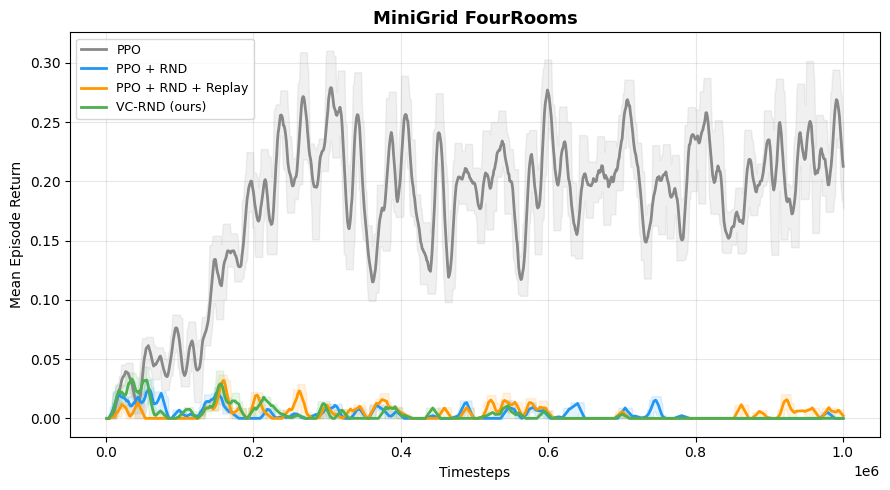

  Saved: /content/drive/MyDrive/CSC415-Project/logs/plots/MiniGrid_FourRooms_vc_analysis.png


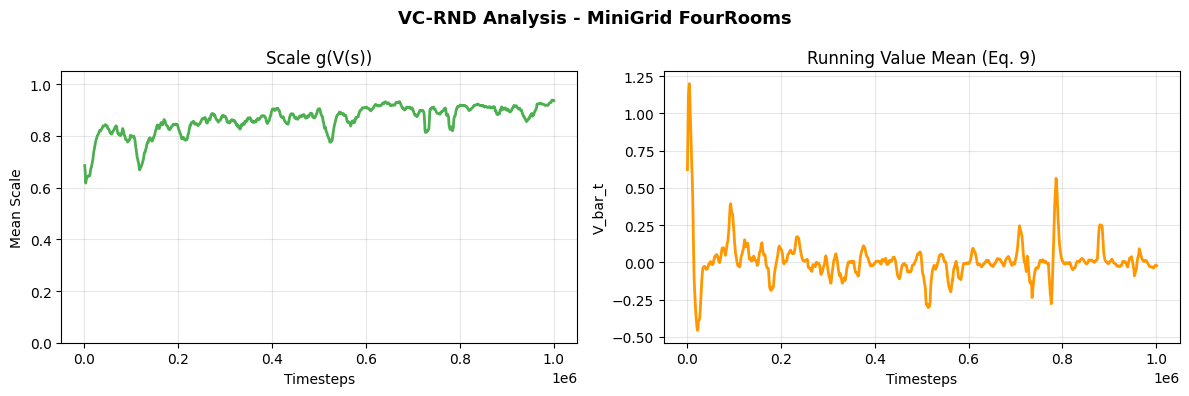

  Saved: /content/drive/MyDrive/CSC415-Project/logs/plots/MiniGrid_FourRooms_intrinsic_dist.png


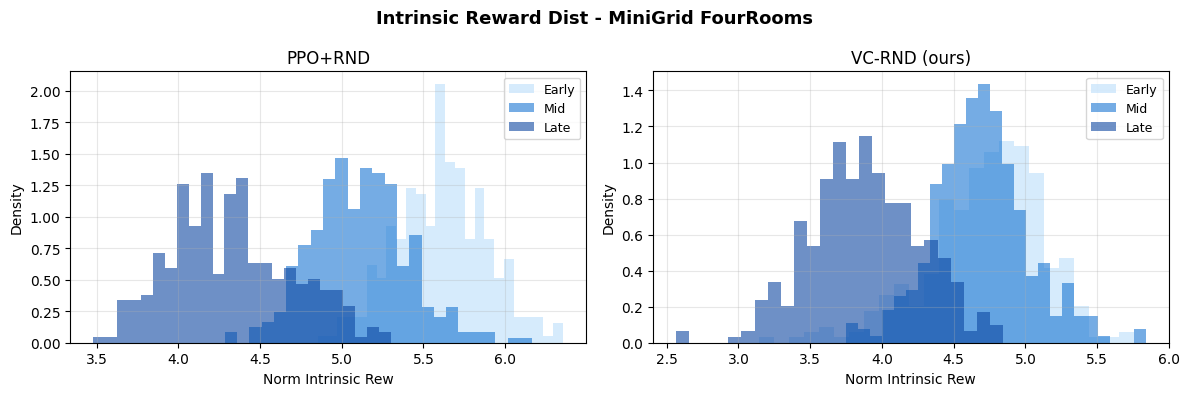


✓ All plots saved to /content/drive/MyDrive/CSC415-Project/logs/plots


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

CONDITIONS = ['ppo', 'ppo_rnd', 'ppo_rnd_replay', 'ppo_vcrnd']
COLORS = {
    'ppo': '#888888', 'ppo_rnd': '#2196F3', 'ppo_rnd_replay': '#FF9800',
    'ppo_vcrnd': '#4CAF50', 'ppo_vcrnd_sigmoid': '#E91E63',
}
LABELS = {
    'ppo': 'PPO', 'ppo_rnd': 'PPO + RND', 'ppo_rnd_replay': 'PPO + RND + Replay',
    'ppo_vcrnd': 'VC-RND (ours)', 'ppo_vcrnd_sigmoid': 'VC-RND sigmoid',
}

def load_csv(base, condition):
    for path in [
        os.path.join(base, condition, 'progress.csv'),
        os.path.join(base, f'{os.path.basename(base)}_{condition}', 'progress.csv'),
    ]:
        if os.path.exists(path):
            return pd.read_csv(path)
    return None

def plot_metric(base_log, env_name, x_col, y_col, y_label, save_dir, smoothing=10, conditions=None):
    conditions = conditions or CONDITIONS
    fig, ax = plt.subplots(figsize=(9, 5)); found = False
    for cond in conditions:
        df = load_csv(base_log, cond)
        if df is None or x_col not in df.columns or y_col not in df.columns: continue
        df = df.dropna(subset=[x_col, y_col])
        s = df[y_col].rolling(smoothing, min_periods=1).mean()
        ax.plot(df[x_col], s, label=LABELS.get(cond, cond), color=COLORS.get(cond, '#333'), lw=2)
        ax.fill_between(df[x_col],
                        df[y_col].rolling(smoothing, min_periods=1).min(),
                        df[y_col].rolling(smoothing, min_periods=1).max(),
                        color=COLORS.get(cond, '#333'), alpha=0.12)
        found = True
    if not found: print(f'  [skip] {env_name} - {y_col}'); plt.close(); return
    ax.set_title(env_name, fontsize=13, fontweight='bold')
    ax.set_xlabel('Timesteps'); ax.set_ylabel(y_label); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fpath = os.path.join(save_dir, f'{env_name.replace(" ","_")}_{y_col}.png')
    os.makedirs(save_dir, exist_ok=True); plt.savefig(fpath, dpi=150)
    print(f'  Saved: {fpath}'); plt.show()

def plot_vc_analysis(base_log, env_name, x_col, save_dir):
    df = load_csv(base_log, 'ppo_vcrnd')
    if df is None: print(f'  [skip] VC analysis - {env_name}'); return
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'VC-RND Analysis - {env_name}', fontsize=13, fontweight='bold')
    ax = axes[0]
    for col in ['vc_scale_mean', 'vc_rnd_scale_mean']:
        if col in df.columns and x_col in df.columns:
            ax.plot(df[x_col], df[col].rolling(10,1).mean(), color='#4CAF50', lw=2)
            ax.set_ylim(0, 1.05); ax.set_xlabel('Timesteps'); ax.set_ylabel('Mean Scale')
            ax.set_title('Scale g(V(s))'); ax.grid(True, alpha=0.3); break
    else: ax.set_title('scale column missing')
    ax = axes[1]
    for col in ['vc_running_value_mean', 'vc_rnd_running_value_mean']:
        if col in df.columns and x_col in df.columns:
            ax.plot(df[x_col], df[col].rolling(10,1).mean(), color='#FF9800', lw=2)
            ax.set_xlabel('Timesteps'); ax.set_ylabel('V_bar_t')
            ax.set_title('Running Value Mean (Eq. 9)'); ax.grid(True, alpha=0.3); break
    else: ax.set_title('value mean column missing')
    plt.tight_layout()
    fpath = os.path.join(save_dir, f'{env_name.replace(" ","_")}_vc_analysis.png')
    plt.savefig(fpath, dpi=150); print(f'  Saved: {fpath}'); plt.show()

def plot_intrinsic_dist(base_log, env_name, save_dir):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'Intrinsic Reward Dist - {env_name}', fontsize=13, fontweight='bold')
    for ax, cond, label in zip(axes, ['ppo_rnd','ppo_vcrnd'], ['PPO+RND','VC-RND (ours)']):
        df = load_csv(base_log, cond)
        if df is None: ax.set_title(f'{label}\n(no data)'); continue
        col = None
        for c in ['mean_int_rew_final','mean_int_rew_norm','rewintmean_norm']:
            if c in df.columns: col = c; break
        if col is None: ax.set_title(f'{label}\n(col missing)'); continue
        n = len(df)
        for third, color, lbl in zip(
            [df.iloc[:n//3], df.iloc[n//3:2*n//3], df.iloc[2*n//3:]],
            ['#bbdefb','#1976d2','#0d47a1'], ['Early','Mid','Late']):
            vals = third[col].dropna()
            if len(vals) > 1: ax.hist(vals, bins=25, alpha=0.6, color=color, label=lbl, density=True)
        ax.set_title(label); ax.set_xlabel('Norm Intrinsic Rew'); ax.set_ylabel('Density')
        ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fpath = os.path.join(save_dir, f'{env_name.replace(" ","_")}_intrinsic_dist.png')
    plt.savefig(fpath, dpi=150); print(f'  Saved: {fpath}'); plt.show()

# ---- Run all plots ----
PLOT_DIR = os.path.join(DRIVE_LOG_DIR, 'plots')


MINIGRID = {
    'MiniGrid FourRooms': f'{DRIVE_LOG_DIR}/minigrid/fourrooms',
    #'MiniGrid MultiRoom': f'{DRIVE_LOG_DIR}/minigrid/multiroom',
}
for name, log in MINIGRID.items():
    print(f'\n-- {name} --')
    plot_metric(log, name, 'timestep', 'mean_ep_rew', 'Mean Episode Return', PLOT_DIR)
    plot_vc_analysis(log, name, 'timestep', PLOT_DIR)
    plot_intrinsic_dist(log, name, PLOT_DIR)


print(f'\n\u2713 All plots saved to {PLOT_DIR}')